In [9]:
!pip install pandas numpy scikit-learn torch matplotlib seaborn tqdm faker

# %%
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix, 
                           accuracy_score, roc_curve, auc, roc_auc_score)
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from faker import Faker
import warnings
import re
import random
from collections import Counter

warnings.filterwarnings('ignore')
fake = Faker()

# Настройка устройства
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f" Используемое устройство: {device}")
print(f" Версия PyTorch: {torch.__version__}")

Defaulting to user installation because normal site-packages is not writeable
 Используемое устройство: cpu
 Версия PyTorch: 2.11.0+cpu


In [10]:
# %%
# Загрузка датасета
df = pd.read_csv('Attack_Dataset.csv')
print(f" Исходный размер датасета: {df.shape}")

# %% [markdown]
# ### Определение веб-уязвимостей (ключевые слова)

# %%
# Ключевые слова для фильтрации веб-уязвимостей
web_vulnerability_keywords = [
    'SQL', 'Injection', 'XSS', 'Cross-Site', 'CSRF', 'SSRF',
    'Authentication Bypass', 'Path Traversal', 'Directory Traversal',
    'Command Injection', 'XXE', 'XML External Entity', 'RCE',
    'Remote Code Execution', 'LFI', 'RFI', 'File Inclusion',
    'Session Hijacking', 'Clickjacking', 'Open Redirect',
    'IDOR', 'Insecure Direct Object Reference', 'CORS',
    'Rate Limiting', 'Brute Force', 'Credential Stuffing'
]

# Фильтрация: оставляем только веб-уязвимости
mask = df['Attack Type'].str.contains('|'.join(web_vulnerability_keywords), 
                                       case=False, na=False) | \
       df['Title'].str.contains('|'.join(web_vulnerability_keywords), 
                                case=False, na=False)

df_web = df[mask].copy()
print(f" После фильтрации веб-уязвимостей: {df_web.shape}")
print(f" Удалено записей: {df.shape[0] - df_web.shape[0]}")

# %%
# Просмотр отфильтрованных категорий
print("\n Категории после фильтрации:")
print(df_web['Category'].value_counts())
print(f"\n Attack Types после фильтрации:")
print(df_web['Attack Type'].value_counts().head(10))



 Исходный размер датасета: (14133, 16)
 После фильтрации веб-уязвимостей: (2853, 16)
 Удалено записей: 11280

 Категории после фильтрации:
Category
Web Application Security                                                                                       297
AI Agents & LLM Exploits                                                                                       241
Quantum Cryptography & Post-Quantum Threats                                                                    179
Wireless Attacks (Advanced)                                                                                    173
Mobile Security                                                                                                153
AI/ML Security                                                                                                 142
Network Security                                                                                               119
Operating System Exploits                      

 Сгенерировано записей 'None Attack': 500

Пример сгенерированной записи:
--------------------------------------------------------------------------------
ID: NA_1
Title: Sell land trade eight man air listen base cause join be.
Category: None Attack
Attack Type: Normal Traffic
Scenario Description: GET /blog - Status: 200 - API call to /health-check returned 200
Tools Used: N/A
Attack Steps: No malicious activity detected
Target Type: Web Application
Vulnerability: None
MITRE Technique: None
Impact: No impact
Detection Method: Normal traffic pattern
Solution: No action required
Tags: normal,benign,legitimate
Source: Generated synthetic data

 Итоговый размер датасета: (3353, 17)
  - Веб-атаки: 2853
  - None Attack (белый шум): 500
  - Соотношение атака/норма: 5.71:1


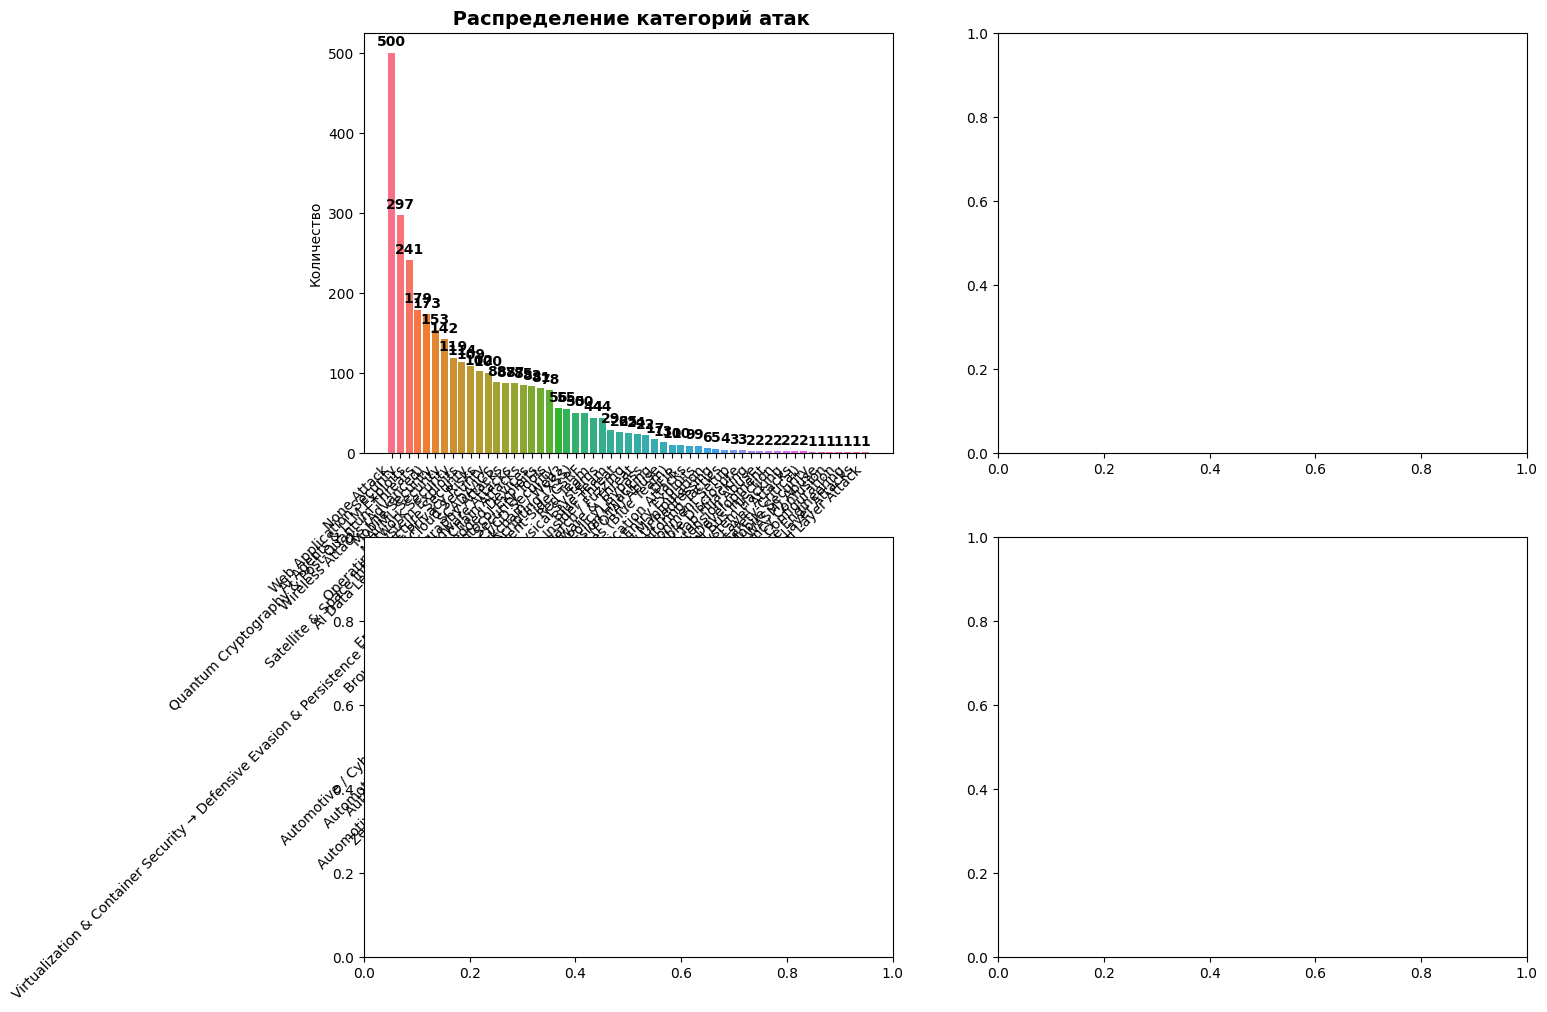

In [11]:
# %% [markdown]
# # БЛОК 3: ГЕНЕРАЦИЯ "БЕЛОГО ШУМА" (NONE ATTACK DATA)

# %%
class WhiteNoiseGenerator:
    """
    Генератор "белого шума" - легитимного трафика без атак
    """
    
    def __init__(self):
        self.normal_actions = [
            "User logged in successfully from IP 192.168.1.100",
            "GET request to /index.html returned 200 OK",
            "User viewed product page with ID 12345",
            "Search query for 'laptop' executed in 0.3 seconds",
            "POST request to /submit-form with valid data",
            "User navigated to /about-us page",
            "Downloaded file report.pdf (2.3 MB)",
            "Session timeout after 30 minutes of inactivity",
            "Password reset email sent to user@example.com",
            "User updated profile information",
            "GET /api/products?category=electronics",
            "User added item to shopping cart",
            "Checkout process completed successfully",
            "User viewed order history",
            "GET request to /images/logo.png",
            "POST request to /contact form submitted",
            "User changed password successfully",
            "Account verification email resent",
            "User logged out of the system",
            "GET request for user avatar image",
            "Search performed with valid parameters",
            "User clicked on recommendation link",
            "Form submitted with all required fields",
            "API call to /health-check returned 200",
            "Static asset loaded from CDN"
        ]
        
        self.safe_urls = [
            "/", "/home", "/about", "/contact", "/products", 
            "/blog", "/api/health", "/static/css/main.css",
            "/static/js/app.js", "/images/logo.png", "/favicon.ico",
            "/robots.txt", "/sitemap.xml", "/login", "/register",
            "/profile", "/settings", "/cart", "/checkout", "/search"
        ]
        
        self.http_methods = ['GET', 'POST', 'PUT', 'DELETE']
        self.status_codes = [200, 201, 301, 302, 304, 400, 401, 403, 404]
    
    def generate_normal_log(self):
        """Генерация одной записи нормального трафика"""
        template = random.choice(self.normal_actions)
        method = random.choice(self.http_methods)
        url = random.choice(self.safe_urls)
        status = random.choices(self.status_codes, weights=[0.7, 0.05, 0.05, 0.05, 0.03, 0.03, 0.03, 0.03, 0.03])[0]
        
        return f"{method} {url} - Status: {status} - {template}"
    
    def generate_dataset(self, num_samples=1000):
        """Генерация датасета нормального трафика"""
        data = []
        for i in range(num_samples):
            row = {
                'ID': f'NA_{i+1}',
                'Title': fake.sentence(nb_words=8),
                'Category': 'None Attack',
                'Attack Type': 'Normal Traffic',
                'Scenario Description': self.generate_normal_log(),
                'Tools Used': 'N/A',
                'Attack Steps': 'No malicious activity detected',
                'Target Type': 'Web Application',
                'Vulnerability': 'None',
                'MITRE Technique': 'None',
                'Impact': 'No impact',
                'Detection Method': 'Normal traffic pattern',
                'Solution': 'No action required',
                'Tags': 'normal,benign,legitimate',
                'Source': 'Generated synthetic data'
            }
            data.append(row)
        
        return pd.DataFrame(data)

# %%
# Генерация "белого шума"
noise_generator = WhiteNoiseGenerator()
df_noise = noise_generator.generate_dataset(num_samples=500)

print(f" Сгенерировано записей 'None Attack': {len(df_noise)}")
print(f"\nПример сгенерированной записи:")
print("-" * 80)
for col, val in df_noise.iloc[0].items():
    print(f"{col}: {val}")

# %%
# Объединение датасетов
df_final = pd.concat([df_web, df_noise], ignore_index=True)
print(f"\n Итоговый размер датасета: {df_final.shape}")
print(f"  - Веб-атаки: {len(df_web)}")
print(f"  - None Attack (белый шум): {len(df_noise)}")
print(f"  - Соотношение атака/норма: {len(df_web)/len(df_noise):.2f}:1")

# %% [markdown]
# # БЛОК 4: СТАТИСТИЧЕСКИЙ АНАЛИЗ ДАННЫХ

# %%
# 4.1 Распределение категорий
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# График 1: Распределение категорий
ax1 = axes[0, 0]
category_counts = df_final['Category'].value_counts()
colors = sns.color_palette('husl', len(category_counts))
bars = ax1.bar(range(len(category_counts)), category_counts.values, color=colors)
ax1.set_xticks(range(len(category_counts)))
ax1.set_xticklabels(category_counts.index, rotation=45, ha='right')
ax1.set_title(' Распределение категорий атак', fontsize=14, fontweight='bold')
ax1.set_ylabel('Количество')
# Добавление значений на столбцы
for bar, val in zip(bars, category_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             str(val), ha='center', va='bottom', fontweight='bold')

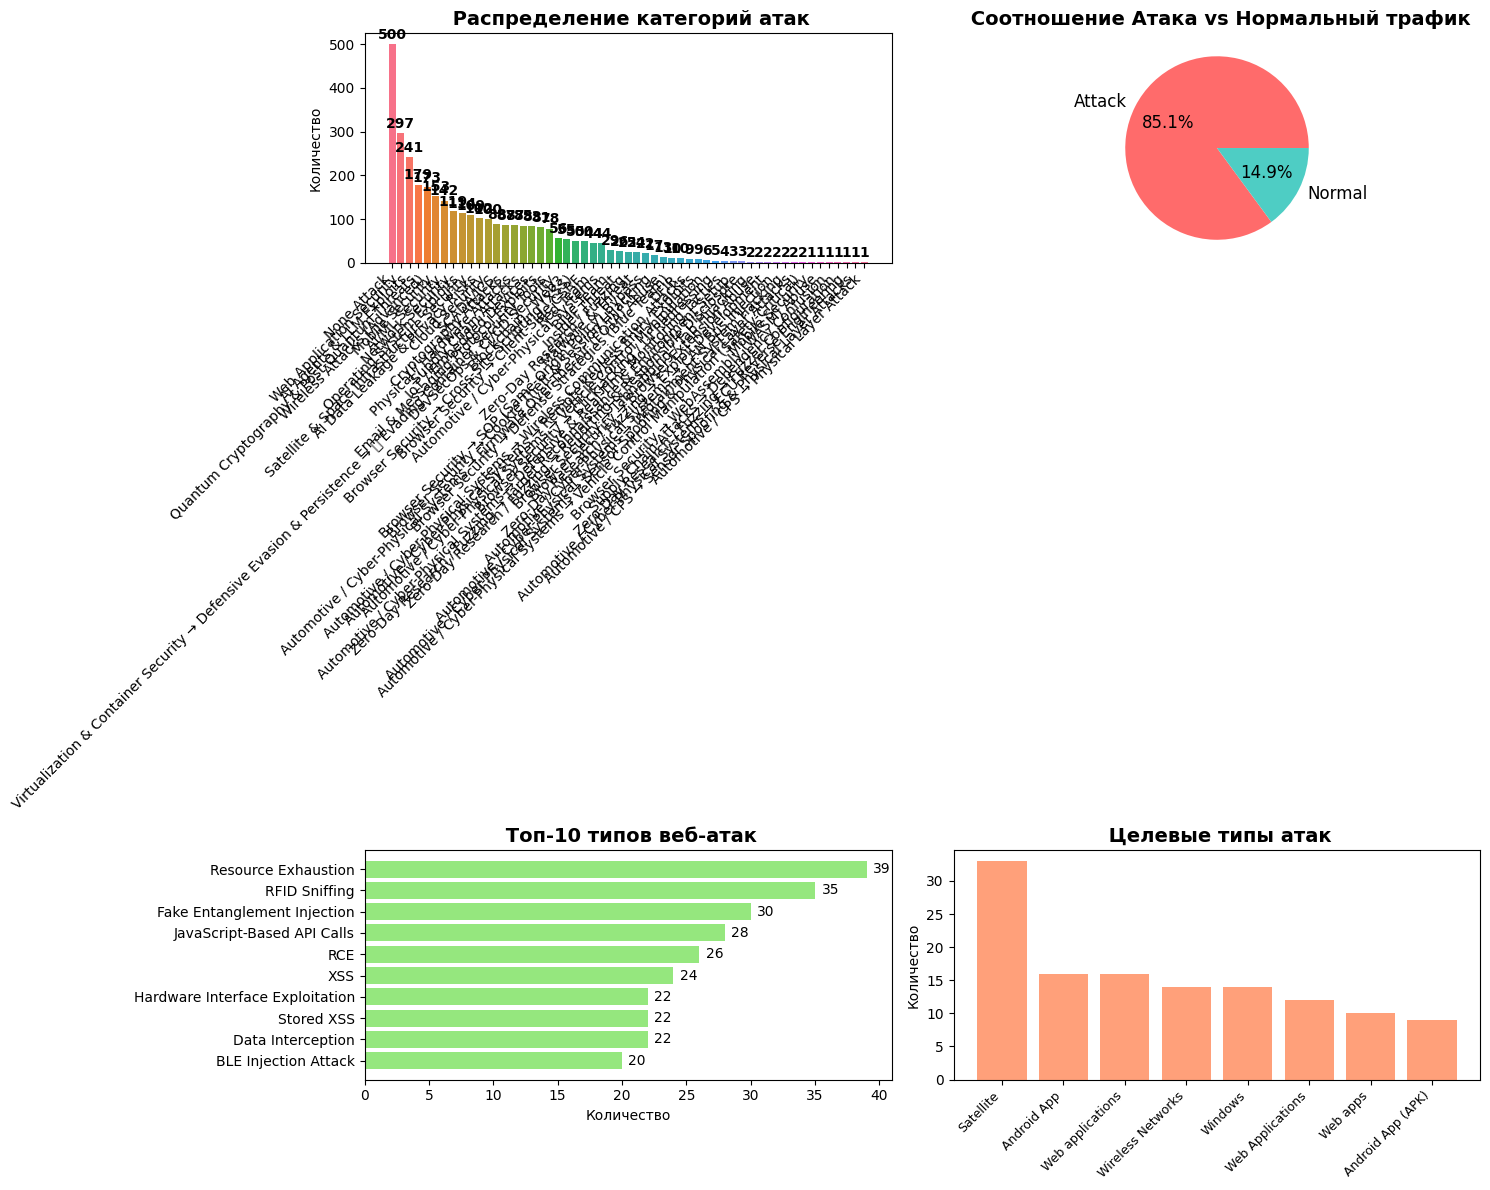

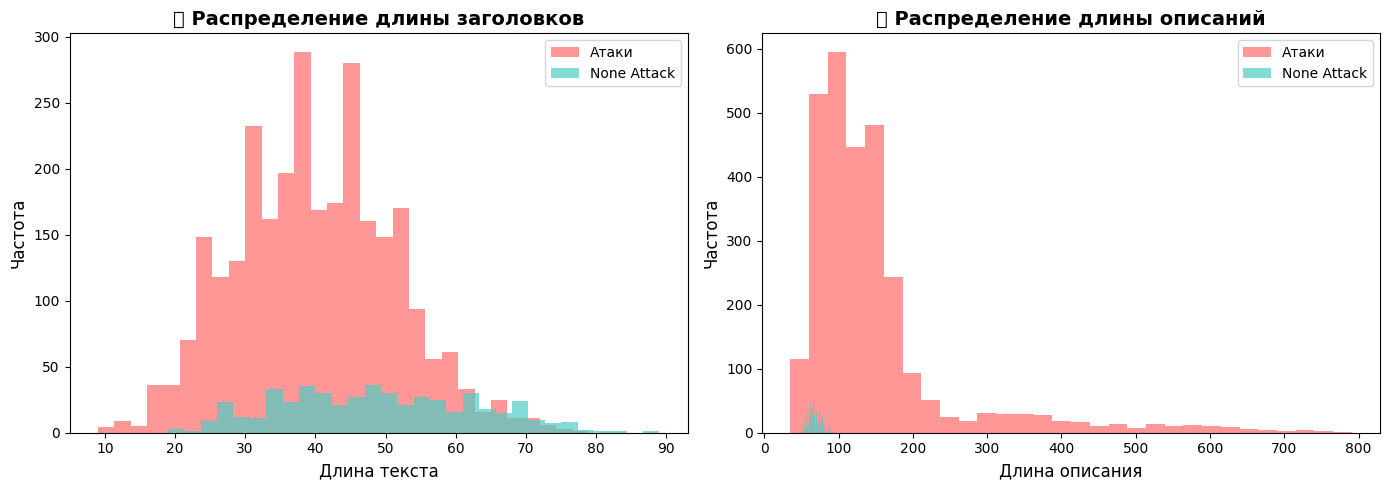


 Статистика длины текстов:
  Атаки - средняя длина заголовка: 39.8
  None Attack - средняя длина заголовка: 48.8


In [12]:
# %% [markdown]
# # БЛОК 4: СТАТИСТИЧЕСКИЙ АНАЛИЗ ДАННЫХ

# %%
# 4.1 Распределение категорий
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# График 1: Распределение категорий
ax1 = axes[0, 0]
category_counts = df_final['Category'].value_counts()
colors = sns.color_palette('husl', len(category_counts))
bars = ax1.bar(range(len(category_counts)), category_counts.values, color=colors)
ax1.set_xticks(range(len(category_counts)))
ax1.set_xticklabels(category_counts.index, rotation=45, ha='right')
ax1.set_title(' Распределение категорий атак', fontsize=14, fontweight='bold')
ax1.set_ylabel('Количество')
# Добавление значений на столбцы
for bar, val in zip(bars, category_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, 
             str(val), ha='center', va='bottom', fontweight='bold')

# График 2: Круговая диаграмма (Attack vs None Attack)
ax2 = axes[0, 1]
attack_vs_normal = df_final['Category'].apply(lambda x: 'Attack' if x != 'None Attack' else 'Normal')
attack_counts = attack_vs_normal.value_counts()
colors_pie = ['#ff6b6b', '#4ecdc4']
wedges, texts, autotexts = ax2.pie(attack_counts.values, labels=attack_counts.index, 
                                    autopct='%1.1f%%', colors=colors_pie,
                                    textprops={'fontsize': 12})
ax2.set_title(' Соотношение Атака vs Нормальный трафик', fontsize=14, fontweight='bold')

# График 3: Топ-10 Attack Types
ax3 = axes[1, 0]
attack_types = df_final[df_final['Category'] != 'None Attack']['Attack Type'].value_counts().head(10)
bars = ax3.barh(range(len(attack_types)), attack_types.values, color='#95e77e')
ax3.set_yticks(range(len(attack_types)))
ax3.set_yticklabels(attack_types.index, fontsize=10)
ax3.set_title(' Топ-10 типов веб-атак', fontsize=14, fontweight='bold')
ax3.set_xlabel('Количество')
ax3.invert_yaxis()
for bar, val in zip(bars, attack_types.values):
    ax3.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
             str(val), ha='left', va='center')

# График 4: Распределение Target Type
ax4 = axes[1, 1]
target_types = df_final[df_final['Category'] != 'None Attack']['Target Type'].value_counts().head(8)
bars = ax4.bar(range(len(target_types)), target_types.values, color='#ffa07a')
ax4.set_xticks(range(len(target_types)))
ax4.set_xticklabels(target_types.index, rotation=45, ha='right', fontsize=9)
ax4.set_title(' Целевые типы атак', fontsize=14, fontweight='bold')
ax4.set_ylabel('Количество')

plt.tight_layout()
plt.show()

# %%
# 4.2 Статистика по длине текстов
df_final['text_length'] = df_final['Title'].fillna('').astype(str).apply(len)
df_final['description_length'] = df_final['Scenario Description'].fillna('').astype(str).apply(len)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Распределение длины заголовков
axes[0].hist(df_final[df_final['Category'] != 'None Attack']['text_length'], 
             bins=30, alpha=0.7, label='Атаки', color='#ff6b6b')
axes[0].hist(df_final[df_final['Category'] == 'None Attack']['text_length'], 
             bins=30, alpha=0.7, label='None Attack', color='#4ecdc4')
axes[0].set_xlabel('Длина текста', fontsize=12)
axes[0].set_ylabel('Частота', fontsize=12)
axes[0].set_title('📏 Распределение длины заголовков', fontsize=14, fontweight='bold')
axes[0].legend()

# Распределение длины описаний
axes[1].hist(df_final[df_final['Category'] != 'None Attack']['description_length'].clip(upper=5000), 
             bins=30, alpha=0.7, label='Атаки', color='#ff6b6b')
axes[1].hist(df_final[df_final['Category'] == 'None Attack']['description_length'].clip(upper=5000), 
             bins=30, alpha=0.7, label='None Attack', color='#4ecdc4')
axes[1].set_xlabel('Длина описания', fontsize=12)
axes[1].set_ylabel('Частота', fontsize=12)
axes[1].set_title('📏 Распределение длины описаний', fontsize=14, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"\n Статистика длины текстов:")
print(f"  Атаки - средняя длина заголовка: {df_final[df_final['Category'] != 'None Attack']['text_length'].mean():.1f}")
print(f"  None Attack - средняя длина заголовка: {df_final[df_final['Category'] == 'None Attack']['text_length'].mean():.1f}")



In [13]:
# %% [markdown]
# # БЛОК 5: ПОДГОТОВКА ДАННЫХ ДЛЯ МОДЕЛИ (С ОБРАБОТКОЙ ОШИБОК)

# %% [markdown]
# ## 5.1 Проверка и очистка данных перед объединением

# %%
# Проверяем типы данных в выбранных столбцах
text_columns = ['Title', 'Attack Type', 'Scenario Description', 'Target Type', 'Tags']

print(" Проверка типов данных в текстовых столбцах:")
for col in text_columns:
    if col in df_final.columns:
        print(f"  {col}: {df_final[col].dtype}")
        # Проверяем наличие NaN
        nan_count = df_final[col].isna().sum()
        if nan_count > 0:
            print(f" Найдено {nan_count} NaN значений - будут заменены на 'Unknown'")
            df_final[col] = df_final[col].fillna('Unknown')
    else:
        print(f"  {col}: СТОЛБЕЦ ОТСУТСТВУЕТ!")
        # Создаем столбец если его нет
        df_final[col] = 'Unknown'

# %%
# Проверяем и конвертируем все значения в строки
print("\n Конвертация всех значений в строковый тип...")
for col in text_columns:
    # Принудительно конвертируем в строку, заменяем любые нестроковые значения
    df_final[col] = df_final[col].astype(str)
    # Заменяем 'nan' на 'Unknown'
    df_final[col] = df_final[col].replace('nan', 'Unknown')
    print(f"  {col}: OK")

# %% [markdown]
# ## 5.2 Объединение текстовых полей

# %%
# Объединение текстовых полей с обработкой ошибок
print("\n Объединение текстовых полей...")

def safe_join(row, columns):
    """Безопасное объединение текстовых полей"""
    texts = []
    for col in columns:
        val = row[col]
        # Убеждаемся что значение - строка
        if isinstance(val, str):
            texts.append(val)
        else:
            texts.append(str(val) if val is not None else 'Unknown')
    return ' '.join(texts)

# Применяем безопасное объединение
df_final['combined_text'] = df_final.apply(lambda row: safe_join(row, text_columns), axis=1)

print(f" Объединение выполнено")
print(f"  Пример результата:\n{df_final['combined_text'].iloc[0][:200]}...")

# %%
# Проверка результата
print(f"\n Статистика по объединенному тексту:")
print(f"  Длина текста (мин): {df_final['combined_text'].str.len().min()}")
print(f"  Длина текста (макс): {df_final['combined_text'].str.len().max()}")
print(f"  Длина текста (сред): {df_final['combined_text'].str.len().mean():.1f}")
print(f"  Пустых строк: {(df_final['combined_text'] == '').sum()}")

# %% [markdown]
# ## 5.3 Кодирование целевых переменных

# %%
# Бинарная классификация (атака vs норма)
df_final['is_attack'] = (df_final['Category'] != 'None Attack').astype(int)

# Мультиклассовая кодировка
le_category = LabelEncoder()
df_final['category_encoded'] = le_category.fit_transform(df_final['Category'])

print(f"\n Целевые переменные:")
print(f"  Бинарная метка (атака/норма):")
for val, count in df_final['is_attack'].value_counts().items():
    label = "Атака" if val == 1 else "Норма"
    print(f"    {label}: {count} ({count/len(df_final)*100:.1f}%)")

print(f"\n  Мультиклассовые метки:")
for i, cat in enumerate(le_category.classes_):
    count = (df_final['category_encoded'] == i).sum()
    print(f"    {cat}: {count} ({count/len(df_final)*100:.1f}%)")

# %% [markdown]
# ## 5.4 Создание класса TextVectorizer

# %%
class TextVectorizer:
    """
    Векторизатор текста для нейронной сети
    Преобразует текст в последовательность индексов
    """
    
    def __init__(self, max_vocab_size=15000, max_sequence_length=200):
        self.max_vocab_size = max_vocab_size
        self.max_sequence_length = max_sequence_length
        self.word_to_idx = {'<PAD>': 0, '<UNK>': 1}
        self.idx_to_word = {0: '<PAD>', 1: '<UNK>'}
        self.vocab_size = 2
    
    def clean_text(self, text):
        """Очистка и нормализация текста"""
        # Приводим к строке
        text = str(text)
        # Приводим к нижнему регистру
        text = text.lower()
        # Удаляем спецсимволы, оставляем буквы, цифры и пробелы
        text = re.sub(r'[^a-zA-Z0-9\s]', ' ', text)
        # Удаляем лишние пробелы
        text = re.sub(r'\s+', ' ', text).strip()
        return text
    
    def build_vocab(self, texts):
        """Построение словаря на основе списка текстов"""
        print(" Построение словаря...")
        word_counter = Counter()
        
        for text in tqdm(texts, desc="Обработка текстов"):
            cleaned = self.clean_text(text)
            words = cleaned.split()
            word_counter.update(words)
        
        # Берем самые частотные слова
        most_common = word_counter.most_common(self.max_vocab_size)
        
        for word, _ in most_common:
            if word not in self.word_to_idx:
                self.word_to_idx[word] = self.vocab_size
                self.idx_to_word[self.vocab_size] = word
                self.vocab_size += 1
        
        print(f" Размер словаря: {self.vocab_size}")
        return self.vocab_size
    
    def text_to_sequence(self, text):
        """Преобразование текста в последовательность индексов"""
        cleaned = self.clean_text(text)
        words = cleaned.split()
        
        # Обрезаем или дополняем последовательность
        if len(words) > self.max_sequence_length:
            words = words[:self.max_sequence_length]
        
        sequence = [self.word_to_idx.get(word, 1) for word in words]
        
        # Дополняем до нужной длины
        if len(sequence) < self.max_sequence_length:
            sequence = sequence + [0] * (self.max_sequence_length - len(sequence))
        
        return sequence
    
    def transform_batch(self, texts):
        """Преобразование батча текстов в последовательности"""
        sequences = []
        for text in texts:
            sequences.append(self.text_to_sequence(text))
        return np.array(sequences)

# %% [markdown]
# ## 5.5 Построение словаря и векторизация

# %%
# Инициализация векторизатора
vectorizer = TextVectorizer(max_vocab_size=15000, max_sequence_length=200)

# Построение словаря на основе объединенных текстов
print("\n Построение словаря на основе текстов...")
vectorizer.build_vocab(df_final['combined_text'].tolist())

# %%
# Векторизация всех текстов
print("\n Векторизация текстов...")
X_sequences = []
for text in tqdm(df_final['combined_text'].tolist(), desc="Векторизация"):
    X_sequences.append(vectorizer.text_to_sequence(text))

X = np.array(X_sequences)
y_binary = df_final['is_attack'].values  # Бинарная классификация
y_multiclass = df_final['category_encoded'].values  # Мультиклассовая

print(f"\n Векторизация завершена:")
print(f"  Форма признаков X: {X.shape}")
print(f"  Форма бинарных меток y_binary: {y_binary.shape}")
print(f"  Форма мультиклассовых меток y_multiclass: {y_multiclass.shape}")

# %%
# Проверка, что нет проблемных значений
print(f"\n Проверка данных:")
print(f"  X содержит NaN: {np.isnan(X).any()}")
print(f"  X содержит inf: {np.isinf(X).any()}")
print(f"  Уникальных значений в X: {len(np.unique(X))}")
print(f"  Диапазон значений в X: [{X.min()}, {X.max()}]")

 Проверка типов данных в текстовых столбцах:
  Title: str
  Attack Type: str
  Scenario Description: str
  Target Type: str
 Найдено 1 NaN значений - будут заменены на 'Unknown'
  Tags: str
 Найдено 1 NaN значений - будут заменены на 'Unknown'

 Конвертация всех значений в строковый тип...
  Title: OK
  Attack Type: OK
  Scenario Description: OK
  Target Type: OK
  Tags: OK

 Объединение текстовых полей...
 Объединение выполнено
  Пример результата:
Authentication Bypass via SQL Injection SQL Injection (SQLi) A login form fails to validate or sanitize input, allowing attackers to log in as admin without knowing the password. Web Login Portals (e....

 Статистика по объединенному тексту:
  Длина текста (мин): 123
  Длина текста (макс): 1014
  Длина текста (сред): 273.8
  Пустых строк: 0

 Целевые переменные:
  Бинарная метка (атака/норма):
    Атака: 2853 (85.1%)
    Норма: 500 (14.9%)

  Мультиклассовые метки:
     Mobile Security: 1 (0.0%)
    AI Agents & LLM Exploits: 241 (7.2%)
    

Обработка текстов: 100%|██████████| 3353/3353 [00:00<00:00, 46109.39it/s]


 Размер словаря: 8736

 Векторизация текстов...


Векторизация: 100%|██████████| 3353/3353 [00:00<00:00, 42069.51it/s]


 Векторизация завершена:
  Форма признаков X: (3353, 200)
  Форма бинарных меток y_binary: (3353,)
  Форма мультиклассовых меток y_multiclass: (3353,)

 Проверка данных:
  X содержит NaN: False
  X содержит inf: False
  Уникальных значений в X: 8735
  Диапазон значений в X: [0, 8735]


In [14]:
# Block 6

# %% [markdown]
# # БЛОК 6: LSTM МОДЕЛЬ

# %%
class AttackLSTM(nn.Module):
    """
    LSTM модель для детекции веб-атак
    
    Архитектура:
    - Embedding слой для преобразования индексов в векторы
    - Двунаправленный LSTM слой (2 слоя)
    - Dropout для регуляризации
    - Полносвязные слои с Batch Normalization
    """
    
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=256, 
                 num_layers=2, num_classes=2, dropout=0.5):
        super(AttackLSTM, self).__init__()
        
        self.embedding_dim = embedding_dim
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.num_classes = num_classes
        
        # Embedding слой
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        
        # Двунаправленный LSTM
        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        
        # Dropout для регуляризации
        self.dropout = nn.Dropout(dropout)
        
        # Полносвязные слои
        # После двунаправленного LSTM размер в 2 раза больше
        self.fc1 = nn.Linear(hidden_dim * 2, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, num_classes)
        
        # Batch normalization для стабилизации обучения
        self.batch_norm1 = nn.BatchNorm1d(128)
        self.batch_norm2 = nn.BatchNorm1d(64)
        
        # Активация
        self.relu = nn.ReLU()
        
    def forward(self, x):
        """
        Forward pass модели
        
        Args:
            x: входные данные [batch_size, seq_len]
        
        Returns:
            выходные логиты [batch_size, num_classes]
        """
        # Embedding
        embedded = self.embedding(x)  # [batch_size, seq_len, embedding_dim]
        
        # LSTM
        lstm_out, (hidden, cell) = self.lstm(embedded)
        
        # Объединяем последние скрытые состояния из обоих направлений
        # hidden shape: [num_layers * 2, batch_size, hidden_dim]
        hidden_last = torch.cat((hidden[-2, :, :], hidden[-1, :, :]), dim=1)
        
        # Полносвязные слои с Dropout и BatchNorm
        out = self.dropout(hidden_last)
        out = self.fc1(out)
        out = self.batch_norm1(out)
        out = self.relu(out)
        
        out = self.dropout(out)
        out = self.fc2(out)
        out = self.batch_norm2(out)
        out = self.relu(out)
        
        out = self.dropout(out)
        out = self.fc3(out)
        
        return out
    
    def get_model_size(self):
        """Подсчет количества параметров модели"""
        total_params = sum(p.numel() for p in self.parameters())
        trainable_params = sum(p.numel() for p in self.parameters() if p.requires_grad)
        return total_params, trainable_params

# %%
class AttackDataset(Dataset):
    """PyTorch Dataset для данных атак"""
    
    def __init__(self, features, labels):
        """
        Args:
            features: numpy array с признаками
            labels: numpy array с метками
        """
        self.features = torch.LongTensor(features)
        self.labels = torch.LongTensor(labels)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return self.features[idx], self.labels[idx]

📊 Разделение данных...

✅ Разделение завершено:
  • Train: 2347 (70.0%)
  • Validation: 503 (15.0%)
  • Test: 503 (15.0%)

⚖️ Баланс классов:
  Train:
    Норма: 350 (14.9%)
    Атака: 1997 (85.1%)
  Validation:
    Норма: 75 (14.9%)
    Атака: 428 (85.1%)
  Test:
    Норма: 75 (14.9%)
    Атака: 428 (85.1%)

✅ DataLoader созданы:
  • Train батчей: 74
  • Validation батчей: 16
  • Test батчей: 16
  • Размер батча: 32
🤖 Модель инициализирована на cpu
📊 Статистика модели:
  • Размер словаря: 8736
  • Embedding размер: 128
  • LSTM hidden размер: 256 (двунаправленный)
  • Количество слоев LSTM: 2
  • Количество классов: 2
  • Всего параметров: 3,560,130
  • Обучаемых параметров: 3,560,130
✅ Оптимизатор и scheduler настроены:
  • Learning rate: 0.001
  • Weight decay: 1e-5
  • Scheduler patience: 5
  • Scheduler factor: 0.5
🚀 НАЧАЛО ОБУЧЕНИЯ

📈 Эпоха 1/50
----------------------------------------


  Train Loss: 0.2799 | Train Acc: 0.8935
  Val Loss:   0.0608 | Val Acc:   1.0000
  LR: 0.001000
  ⭐ Новая лучшая модель! (Acc: 1.0000)

📈 Эпоха 2/50
----------------------------------------


  Train Loss: 0.0293 | Train Acc: 1.0000
  Val Loss:   0.0095 | Val Acc:   1.0000
  LR: 0.001000

📈 Эпоха 3/50
----------------------------------------


  Train Loss: 0.0102 | Train Acc: 1.0000
  Val Loss:   0.0040 | Val Acc:   1.0000
  LR: 0.001000

📈 Эпоха 4/50
----------------------------------------


  Train Loss: 0.0079 | Train Acc: 1.0000
  Val Loss:   0.0022 | Val Acc:   1.0000
  LR: 0.001000

📈 Эпоха 5/50
----------------------------------------


...

  Train Loss: 0.0055 | Train Acc: 0.9983
  Val Loss:   0.0000 | Val Acc:   1.0000
  LR: 0.000500

📈 Эпоха 47/50
----------------------------------------


  Train Loss: 0.0012 | Train Acc: 1.0000
  Val Loss:   0.0000 | Val Acc:   1.0000
  LR: 0.000500

📈 Эпоха 48/50
----------------------------------------


  Train Loss: 0.0004 | Train Acc: 1.0000
  Val Loss:   0.0000 | Val Acc:   1.0000
  LR: 0.000500

📈 Эпоха 49/50
----------------------------------------


  Train Loss: 0.0057 | Train Acc: 0.9996
  Val Loss:   0.0000 | Val Acc:   1.0000
  LR: 0.000500

📈 Эпоха 50/50
----------------------------------------


  Train Loss: 0.0007 | Train Acc: 1.0000
  Val Loss:   0.0000 | Val Acc:   1.0000
  LR: 0.000500

✅ ОБУЧЕНИЕ ЗАВЕРШЕНО!
🏆 Лучшая валидационная точность: 1.0000 (100.00%)

📊 Последние 5 эпох обучения:
    train_loss  train_acc  val_loss  val_acc
45    0.005494   0.998296  0.000007      1.0
46    0.001184   1.000000  0.000004      1.0
47    0.000388   1.000000  0.000004      1.0
48    0.005663   0.999574  0.000001      1.0
49    0.000742   1.000000  0.000002      1.0


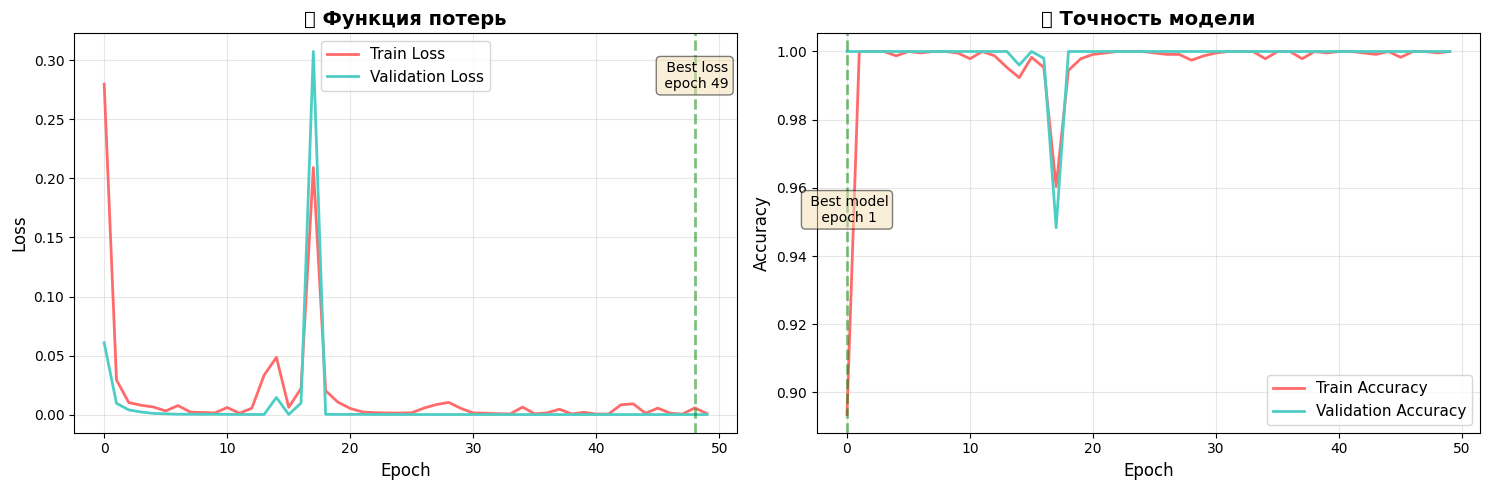


📊 Статистика обучения:
  • Минимальная val loss: 0.0000 (эпоха 49)
  • Максимальная val accuracy: 1.0000 (эпоха 1)
  • Финальная val accuracy: 1.0000
  • Разница между train и val accuracy: 0.0000

✅ Модель хорошо обобщает: переобучение не обнаружено


In [15]:
# -*- coding: utf-8 -*-
"""
# БЛОК 7: РАЗДЕЛЕНИЕ ДАННЫХ И ОБУЧЕНИЕ (ИСПРАВЛЕННАЯ ВЕРСИЯ)
"""

# %% [markdown]
# ## 7.1 Разделение на train/val/test

# %%
from sklearn.model_selection import train_test_split

print("📊 Разделение данных...")

# Сначала разделяем на train (70%) и temp (30%)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_binary, 
    test_size=0.3, 
    random_state=42, 
    stratify=y_binary
)

# Затем разделяем temp на validation (15%) и test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, 
    test_size=0.5, 
    random_state=42, 
    stratify=y_temp
)

print(f"\n✅ Разделение завершено:")
print(f"  • Train: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  • Validation: {X_val.shape[0]} ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"  • Test: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")

# %%
# Проверка баланса классов в каждом разделе
def check_class_balance(y, name):
    unique, counts = np.unique(y, return_counts=True)
    print(f"  {name}:")
    for u, c in zip(unique, counts):
        class_name = "Атака" if u == 1 else "Норма"
        print(f"    {class_name}: {c} ({c/len(y)*100:.1f}%)")

print("\n⚖️ Баланс классов:")
check_class_balance(y_train, "Train")
check_class_balance(y_val, "Validation")
check_class_balance(y_test, "Test")

# %% [markdown]
# ## 7.2 Создание DataLoader

# %%
from torch.utils.data import DataLoader

# Создание датасетов
train_dataset = AttackDataset(X_train, y_train)
val_dataset = AttackDataset(X_val, y_val)
test_dataset = AttackDataset(X_test, y_test)

# Параметры DataLoader
batch_size = 32
num_workers = 0  # Для Windows лучше использовать 0

# Создание DataLoader
train_loader = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True,
    num_workers=num_workers
)

val_loader = DataLoader(
    val_dataset, 
    batch_size=batch_size, 
    shuffle=False,
    num_workers=num_workers
)

test_loader = DataLoader(
    test_dataset, 
    batch_size=batch_size, 
    shuffle=False,
    num_workers=num_workers
)

print(f"\n✅ DataLoader созданы:")
print(f"  • Train батчей: {len(train_loader)}")
print(f"  • Validation батчей: {len(val_loader)}")
print(f"  • Test батчей: {len(test_loader)}")
print(f"  • Размер батча: {batch_size}")

# %% [markdown]
# ## 7.3 Инициализация модели

# %%
# Инициализация модели
vocab_size = vectorizer.vocab_size
num_classes = 2  # Бинарная классификация

model = AttackLSTM(
    vocab_size=vocab_size,
    embedding_dim=128,
    hidden_dim=256,
    num_layers=2,
    num_classes=num_classes,
    dropout=0.5
).to(device)

# Подсчет параметров
total_params, trainable_params = model.get_model_size()

print(f"🤖 Модель инициализирована на {device}")
print(f"📊 Статистика модели:")
print(f"  • Размер словаря: {vocab_size}")
print(f"  • Embedding размер: 128")
print(f"  • LSTM hidden размер: 256 (двунаправленный)")
print(f"  • Количество слоев LSTM: 2")
print(f"  • Количество классов: {num_classes}")
print(f"  • Всего параметров: {total_params:,}")
print(f"  • Обучаемых параметров: {trainable_params:,}")

# %% [markdown]
# ## 7.4 Настройка оптимизатора и функции потерь

# %%
# Функция потерь для бинарной классификации
criterion = nn.CrossEntropyLoss()

# Оптимизатор AdamW с weight decay для регуляризации
optimizer = optim.AdamW(
    model.parameters(), 
    lr=0.001, 
    weight_decay=1e-5
)

# Scheduler для уменьшения learning rate при затухании обучения
# Убираем параметр verbose, так как он устарел
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min', 
    patience=5, 
    factor=0.5
)

print("✅ Оптимизатор и scheduler настроены:")
print(f"  • Learning rate: 0.001")
print(f"  • Weight decay: 1e-5")
print(f"  • Scheduler patience: 5")
print(f"  • Scheduler factor: 0.5")

# %% [markdown]
# ## 7.5 Функции обучения и валидации

# %%
def train_epoch(model, loader, criterion, optimizer, device):
    """
    Обучение одной эпохи
    
    Returns:
        avg_loss: средняя потеря
        accuracy: точность на эпохе
    """
    model.train()
    total_loss = 0
    all_preds = []
    all_labels = []
    
    for features, labels in tqdm(loader, desc="Training", leave=False):
        # Перемещаем данные на устройство
        features = features.to(device)
        labels = labels.to(device)
        
        # Обнуляем градиенты
        optimizer.zero_grad()
        
        # Forward pass
        outputs = model(features)
        loss = criterion(outputs, labels)
        
        # Backward pass
        loss.backward()
        
        # Gradient clipping для стабильности
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        # Обновляем веса
        optimizer.step()
        
        # Сохраняем метрики
        total_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    avg_loss = total_loss / len(loader)
    accuracy = accuracy_score(all_labels, all_preds)
    
    return avg_loss, accuracy

def validate(model, loader, criterion, device):
    """
    Валидация модели
    
    Returns:
        avg_loss: средняя потеря
        accuracy: точность
        all_preds: все предсказания
        all_labels: все метки
        all_probs: все вероятности
    """
    model.eval()
    total_loss = 0
    all_preds = []
    all_labels = []
    all_probs = []
    
    with torch.no_grad():
        for features, labels in tqdm(loader, desc="Validation", leave=False):
            features = features.to(device)
            labels = labels.to(device)
            
            outputs = model(features)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            probs = torch.softmax(outputs, dim=1)
            _, preds = torch.max(outputs, 1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
    
    avg_loss = total_loss / len(loader)
    accuracy = accuracy_score(all_labels, all_preds)
    
    return avg_loss, accuracy, all_preds, all_labels, all_probs

# %% [markdown]
# ## 7.6 Запуск обучения

# %%
# Параметры обучения
num_epochs = 50
best_val_acc = 0
best_model_state = None

# История обучения
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

print("🚀 НАЧАЛО ОБУЧЕНИЯ")
print("=" * 50)

for epoch in range(num_epochs):
    print(f"\n📈 Эпоха {epoch + 1}/{num_epochs}")
    print("-" * 40)
    
    # Обучение
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    
    # Валидация
    val_loss, val_acc, _, _, _ = validate(model, val_loader, criterion, device)
    
    # Сохраняем историю
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    # Обновляем learning rate
    old_lr = optimizer.param_groups[0]['lr']
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    # Выводим результаты
    print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.4f}")
    print(f"  LR: {current_lr:.6f}")
    
    if current_lr != old_lr:
        print(f"  🔄 Learning rate изменен: {old_lr:.6f} -> {current_lr:.6f}")
    
    # Сохраняем лучшую модель
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        best_model_state = model.state_dict().copy()
        print(f"  ⭐ Новая лучшая модель! (Acc: {val_acc:.4f})")

print("\n" + "=" * 50)
print(f"✅ ОБУЧЕНИЕ ЗАВЕРШЕНО!")
print(f"🏆 Лучшая валидационная точность: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")

# %%
# Сохраняем историю обучения для последующего анализа
history_df = pd.DataFrame(history)
print("\n📊 Последние 5 эпох обучения:")
print(history_df.tail())

# %%
# Визуализация процесса обучения
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# График потерь
axes[0].plot(history['train_loss'], label='Train Loss', linewidth=2, color='#ff6b6b')
axes[0].plot(history['val_loss'], label='Validation Loss', linewidth=2, color='#4ecdc4')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('📉 Функция потерь', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Находим эпоху с минимальной валидационной потерей
min_val_loss_epoch = np.argmin(history['val_loss'])
axes[0].axvline(x=min_val_loss_epoch, color='green', linestyle='--', alpha=0.5, linewidth=2)
axes[0].text(min_val_loss_epoch, max(history['val_loss']) * 0.9, 
             f' Best loss\n epoch {min_val_loss_epoch+1}', 
             ha='center', fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# График точности
axes[1].plot(history['train_acc'], label='Train Accuracy', linewidth=2, color='#ff6b6b')
axes[1].plot(history['val_acc'], label='Validation Accuracy', linewidth=2, color='#4ecdc4')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy', fontsize=12)
axes[1].set_title('📈 Точность модели', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

# Находим эпоху с максимальной валидационной точностью
max_val_acc_epoch = np.argmax(history['val_acc'])
axes[1].axvline(x=max_val_acc_epoch, color='green', linestyle='--', alpha=0.5, linewidth=2)
axes[1].text(max_val_acc_epoch, max(history['val_acc']) * 0.95, 
             f' Best model\n epoch {max_val_acc_epoch+1}', 
             ha='center', fontsize=10, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# Вывод статистики обучения
print("\n📊 Статистика обучения:")
print(f"  • Минимальная val loss: {min(history['val_loss']):.4f} (эпоха {np.argmin(history['val_loss'])+1})")
print(f"  • Максимальная val accuracy: {max(history['val_acc']):.4f} (эпоха {np.argmax(history['val_acc'])+1})")
print(f"  • Финальная val accuracy: {history['val_acc'][-1]:.4f}")
print(f"  • Разница между train и val accuracy: {history['train_acc'][-1] - history['val_acc'][-1]:.4f}")

# Проверка на переобучение
if history['train_acc'][-1] - history['val_acc'][-1] > 0.1:
    print("\n⚠️ ВНИМАНИЕ: Возможно переобучение!")
    print(f"   Разница между train и val accuracy: {history['train_acc'][-1] - history['val_acc'][-1]:.4f}")
else:
    print("\n✅ Модель хорошо обобщает: переобучение не обнаружено")

 Загружена лучшая модель



 РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ
  Test Loss:     0.0000
  Test Accuracy: 1.0000 (100.00%)

 CLASSIFICATION REPORT
                                    precision    recall  f1-score   support

Normal Traffic (Безопасный трафик)       1.00      1.00      1.00        75
            Web Attack (Веб-атака)       1.00      1.00      1.00       428

                          accuracy                           1.00       503
                         macro avg       1.00      1.00      1.00       503
                      weighted avg       1.00      1.00      1.00       503


 ДЕТАЛЬНЫЕ МЕТРИКИ
  Матрица ошибок:
    True Positives (TP):  428  - атаки правильно обнаружены
    True Negatives (TN):  75  - нормальный трафик правильно классифицирован
    False Positives (FP): 0  - ложные тревоги (нормальный трафик принят за атаку)
    False Negatives (FN): 0  - пропущенные атаки

  Precision (Точность):     1.0000  - из всех предсказанных атак, сколько是真的
  Recall (Полнота):         1.0000  - из вс

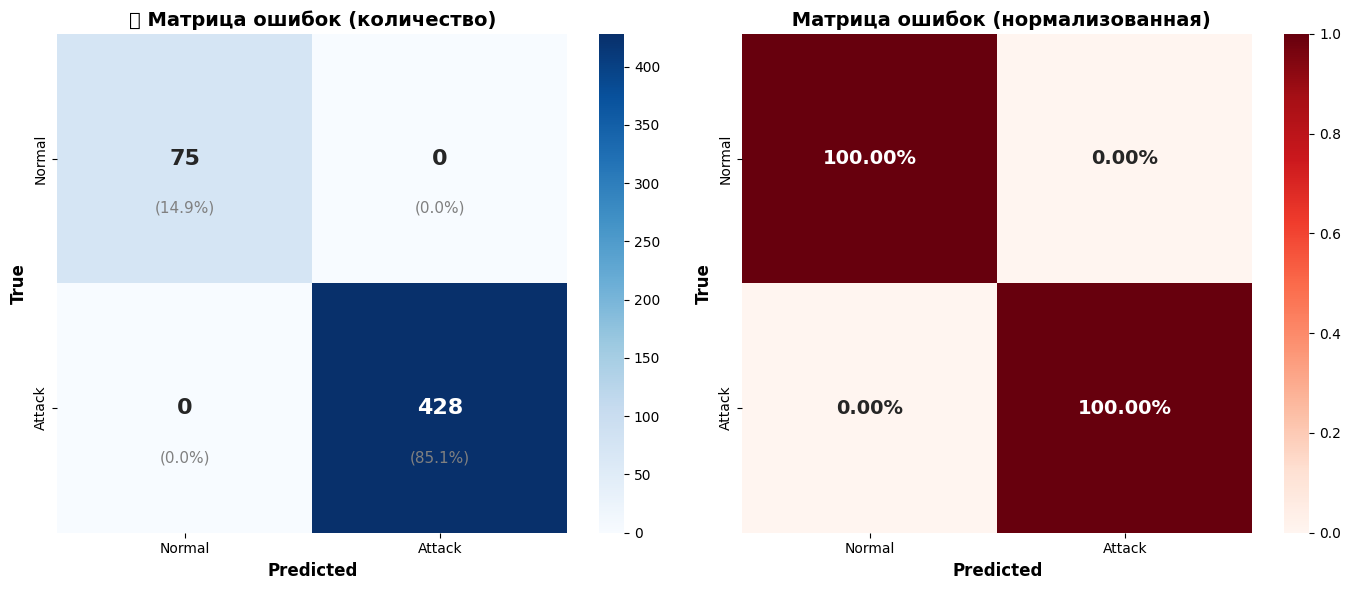

In [16]:
# -*- coding: utf-8 -*-
"""
# БЛОК 8: ТЕСТИРОВАНИЕ И ОЦЕНКА КАЧЕСТВА МОДЕЛИ
"""

# %% [markdown]
# ## 8.1 Загрузка лучшей модели и тестирование

# %%
# Загружаем лучшую модель
model.load_state_dict(best_model_state)
print(" Загружена лучшая модель")

# Тестирование на тестовой выборке
test_loss, test_acc, test_preds, test_labels, test_probs = validate(
    model, test_loader, criterion, device
)

print("\n РЕЗУЛЬТАТЫ НА ТЕСТОВОЙ ВЫБОРКЕ")
print("=" * 50)
print(f"  Test Loss:     {test_loss:.4f}")
print(f"  Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

# %% [markdown]
# ## 8.2 Детальный Classification Report

# %%
from sklearn.metrics import classification_report, precision_score, recall_score, f1_score

print("\n CLASSIFICATION REPORT")
print("=" * 50)
target_names = ['Normal Traffic (Безопасный трафик)', 'Web Attack (Веб-атака)']
print(classification_report(test_labels, test_preds, target_names=target_names))

# %% [markdown]
# ## 8.3 Вычисление всех метрик

# %%
from sklearn.metrics import confusion_matrix

# Матрица ошибок
cm = confusion_matrix(test_labels, test_preds)
tn, fp, fn, tp = cm.ravel()

# Вычисление метрик
precision = precision_score(test_labels, test_preds)
recall = recall_score(test_labels, test_preds)
f1 = f1_score(test_labels, test_preds)
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
balanced_accuracy = (recall + specificity) / 2

print("\n ДЕТАЛЬНЫЕ МЕТРИКИ")
print("=" * 50)
print(f"  Матрица ошибок:")
print(f"    True Positives (TP):  {tp}  - атаки правильно обнаружены")
print(f"    True Negatives (TN):  {tn}  - нормальный трафик правильно классифицирован")
print(f"    False Positives (FP): {fp}  - ложные тревоги (нормальный трафик принят за атаку)")
print(f"    False Negatives (FN): {fn}  - пропущенные атаки")
print(f"\n  Precision (Точность):     {precision:.4f}  - из всех предсказанных атак, сколько是真的")
print(f"  Recall (Полнота):         {recall:.4f}  - из всех реальных атак, сколько найдено")
print(f"  F1-Score:                 {f1:.4f}  - гармоническое среднее precision и recall")
print(f"  Specificity (Специфичность): {specificity:.4f}  - из всего нормального трафика, сколько правильно")
print(f"  Balanced Accuracy:        {balanced_accuracy:.4f}  - среднее recall и specificity")

# %% [markdown]
# ## 8.4 Визуализация матрицы ошибок

# %%
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# График 1: Матрица ошибок (количество)
ax1 = axes[0]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Attack'], 
            yticklabels=['Normal', 'Attack'],
            annot_kws={'size': 16, 'weight': 'bold'},
            ax=ax1)
ax1.set_xlabel('Predicted', fontsize=12, fontweight='bold')
ax1.set_ylabel('True', fontsize=12, fontweight='bold')
ax1.set_title('🔍 Матрица ошибок (количество)', fontsize=14, fontweight='bold')

# Добавляем проценты
for i in range(2):
    for j in range(2):
        percentage = cm[i, j] / cm.sum() * 100
        ax1.text(j+0.5, i+0.7, f'({percentage:.1f}%)', 
                ha='center', va='center', fontsize=11, color='gray')

# График 2: Нормализованная матрица ошибок (проценты)
ax2 = axes[1]
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Reds',
            xticklabels=['Normal', 'Attack'], 
            yticklabels=['Normal', 'Attack'],
            annot_kws={'size': 14, 'weight': 'bold'},
            ax=ax2)
ax2.set_xlabel('Predicted', fontsize=12, fontweight='bold')
ax2.set_ylabel('True', fontsize=12, fontweight='bold')
ax2.set_title(' Матрица ошибок (нормализованная)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()



 ROC-AUC Score: 1.0000
   Интерпретация: Отличное качество классификации 


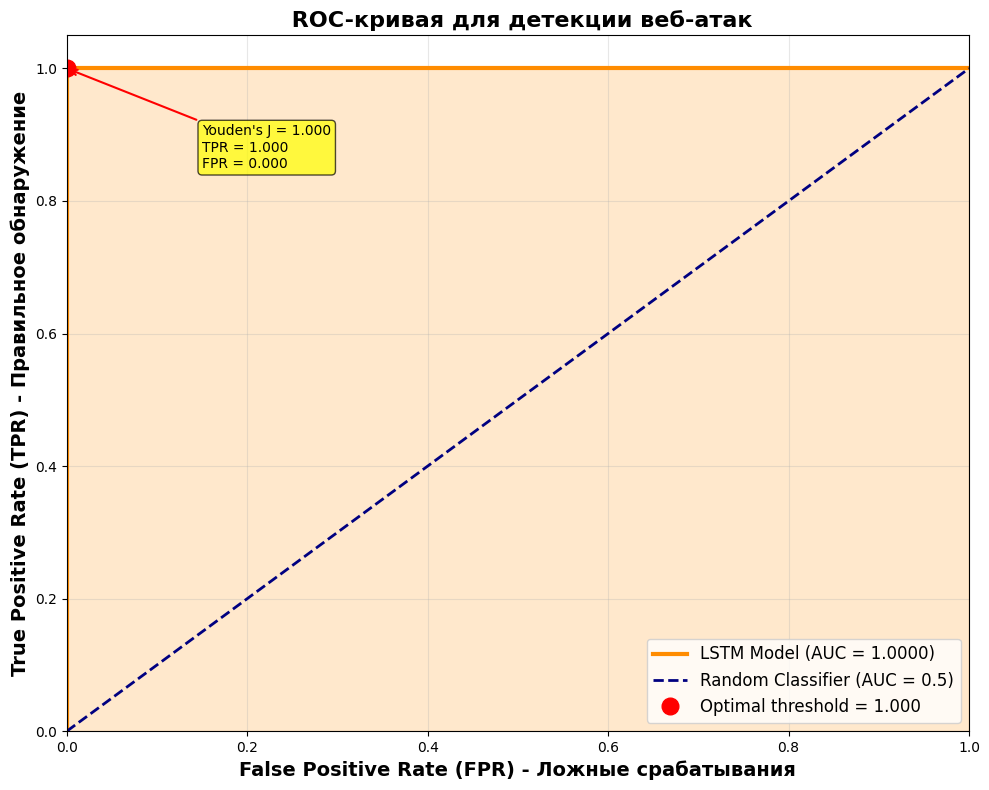


 Анализ оптимального порога:
  • Оптимальный порог: 1.0000
  • True Positive Rate при этом пороге: 1.0000
  • False Positive Rate при этом пороге: 0.0000
  • Youden's J statistic: 1.0000
 АНАЛИЗ ОШИБОК МОДЕЛИ
Всего ошибок: 0 из 503 (0.00%)

  • False Positives (ложные тревоги): 0
  • False Negatives (пропущенные атаки): 0


In [17]:
# %% [markdown]
# # БЛОК 9: ROC-КРИВАЯ И АНАЛИЗ ПОРОГА

# %%
from sklearn.metrics import roc_curve, auc, roc_auc_score

# Получаем вероятности для ROC-кривой
model.eval()
all_probs = []
all_labels_list = []

with torch.no_grad():
    for features, labels in test_loader:
        features = features.to(device)
        outputs = model(features)
        probs = torch.softmax(outputs, dim=1)
        all_probs.extend(probs.cpu().numpy()[:, 1])  # Вероятность класса "атака"
        all_labels_list.extend(labels.numpy())

# Вычисление ROC
fpr, tpr, thresholds = roc_curve(all_labels_list, all_probs)
roc_auc = auc(fpr, tpr)

print(f" ROC-AUC Score: {roc_auc:.4f}")
print(f"   Интерпретация: ", end="")
if roc_auc >= 0.9:
    print("Отличное качество классификации ")
elif roc_auc >= 0.8:
    print("Хорошее качество классификации ")
elif roc_auc >= 0.7:
    print("Удовлетворительное качество классификации ")
else:
    print("Низкое качество классификации ")

# %%
# Построение ROC-кривой
fig, ax = plt.subplots(figsize=(10, 8))

# Основная ROC кривая
ax.plot(fpr, tpr, color='darkorange', lw=3, 
        label=f'LSTM Model (AUC = {roc_auc:.4f})')

# Линия случайного классификатора
ax.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
        label='Random Classifier (AUC = 0.5)')

# Заливка области под кривой
ax.fill_between(fpr, tpr, alpha=0.2, color='darkorange')

# Настройка осей
ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel('False Positive Rate (FPR) - Ложные срабатывания', fontsize=14, fontweight='bold')
ax.set_ylabel('True Positive Rate (TPR) - Правильное обнаружение', fontsize=14, fontweight='bold')
ax.set_title(' ROC-кривая для детекции веб-атак', fontsize=16, fontweight='bold')

# Добавление сетки
ax.grid(True, alpha=0.3)

# Поиск оптимального порога (Youden's J statistic)
youden_j = tpr - fpr
optimal_idx = np.argmax(youden_j)
optimal_threshold = thresholds[optimal_idx] if optimal_idx < len(thresholds) else 0.5
optimal_tpr = tpr[optimal_idx]
optimal_fpr = fpr[optimal_idx]

# Отмечаем оптимальную точку
ax.plot(optimal_fpr, optimal_tpr, 'ro', markersize=12, 
        label=f'Optimal threshold = {optimal_threshold:.3f}')

# Добавляем аннотацию
ax.annotate(f'Youden\'s J = {youden_j[optimal_idx]:.3f}\nTPR = {optimal_tpr:.3f}\nFPR = {optimal_fpr:.3f}',
            xy=(optimal_fpr, optimal_tpr),
            xytext=(optimal_fpr + 0.15, optimal_tpr - 0.15),
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5),
            fontsize=10, 
            bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.7))

# Легенда
ax.legend(loc="lower right", fontsize=12)

plt.tight_layout()
plt.show()

print(f"\n Анализ оптимального порога:")
print(f"  • Оптимальный порог: {optimal_threshold:.4f}")
print(f"  • True Positive Rate при этом пороге: {optimal_tpr:.4f}")
print(f"  • False Positive Rate при этом пороге: {optimal_fpr:.4f}")
print(f"  • Youden's J statistic: {youden_j[optimal_idx]:.4f}")

# %% [markdown]
# # БЛОК 10: АНАЛИЗ ОШИБОК МОДЕЛИ

# %%
# Находим примеры, где модель ошиблась
misclassified_indices = [i for i, (true, pred) in enumerate(zip(test_labels, test_preds)) if true != pred]

print(f" АНАЛИЗ ОШИБОК МОДЕЛИ")
print("=" * 50)
print(f"Всего ошибок: {len(misclassified_indices)} из {len(test_labels)} ({len(misclassified_indices)/len(test_labels)*100:.2f}%)")

# Разделяем ошибки по типам
false_positives = [(i, test_probs[i][1]) for i in misclassified_indices if test_labels[i] == 0]  # Атака предсказана, но это норма
false_negatives = [(i, test_probs[i][1]) for i in misclassified_indices if test_labels[i] == 1]  # Норма предсказана, но это атака

print(f"\n  • False Positives (ложные тревоги): {len(false_positives)}")
print(f"  • False Negatives (пропущенные атаки): {len(false_negatives)}")

# %%
# Показываем примеры ошибок
if len(false_positives) > 0:
    print("\n ПРИМЕРЫ FALSE POSITIVES (нормальный трафик, принятый за атаку):")
    print("-" * 60)
    for i, prob in false_positives[:5]:  # Показываем первые 5
        text_preview = df_final.iloc[i]['combined_text'][:150]
        print(f"  Текст: {text_preview}...")
        print(f"  Вероятность атаки: {prob:.4f}")
        print()

if len(false_negatives) > 0:
    print("\n ПРИМЕРЫ FALSE NEGATIVES (пропущенные атаки):")
    print("-" * 60)
    for i, prob in false_negatives[:5]:  # Показываем первые 5
        text_preview = df_final.iloc[i]['combined_text'][:150]
        print(f"  Текст: {text_preview}...")
        print(f"  Вероятность атаки: {prob:.4f}")
        print()



In [18]:
# %% [markdown]
# # БЛОК 11: ПРЕДСКАЗАНИЕ НА РЕАЛЬНЫХ ПРИМЕРАХ

# %%
def predict_attack(text, model, vectorizer, device, threshold=0.5):
    """
    Предсказание для одного текста
    
    Args:
        text: текст для анализа
        model: обученная модель
        vectorizer: векторизатор
        device: устройство
        threshold: порог классификации
    
    Returns:
        is_attack: является ли атакой (bool)
        probability: вероятность атаки
        confidence: уверенность в предсказании
    """
    model.eval()
    
    # Векторизация
    sequence = vectorizer.text_to_sequence(text)
    input_tensor = torch.LongTensor([sequence]).to(device)
    
    # Предсказание
    with torch.no_grad():
        outputs = model(input_tensor)
        probs = torch.softmax(outputs, dim=1)
        attack_prob = probs[0][1].item()
    
    # Применяем порог
    is_attack = attack_prob >= threshold
    confidence = attack_prob if is_attack else 1 - attack_prob
    
    return is_attack, attack_prob, confidence

# %%
# Тестовые примеры для валидации
test_cases = [
    # Веб-атаки
    ("' OR '1'='1' -- SQL Injection attack on login form to bypass authentication", True),
    ("<script>alert('XSS')</script> Cross-site scripting vulnerability in comment section", True),
    ("../../../../etc/passwd Path traversal attack to read sensitive files", True),
    ("; rm -rf / Command injection attempt to execute system commands", True),
    ("SELECT * FROM users WHERE username = 'admin' --", True),
    ("<img src=x onerror=alert(1)> XSS payload in image tag", True),
    ("admin' OR '1'='1' --", True),
    
    # Нормальный трафик
    ("User logged in successfully from IP 192.168.1.100 at 2024-01-15 10:30:00", False),
    ("GET request to /index.html returned status code 200 OK", False),
    ("User viewed product page with ID 12345 and added to cart", False),
    ("Password reset email sent to user@example.com successfully", False),
    ("Search query for 'laptop' executed in 0.3 seconds returned 50 results", False),
    ("User updated profile information: changed email address", False),
    ("GET /api/products?category=electronics returns product list", False),
]

# %%
# Выполнение предсказаний
print(" ТЕСТИРОВАНИЕ НА РЕАЛЬНЫХ ПРИМЕРАХ")
print("=" * 70)

results = []
for text, expected in test_cases:
    is_attack, prob, confidence = predict_attack(text, model, vectorizer, device, threshold=optimal_threshold)
    
    # Определяем результат
    if is_attack == expected:
        status = "✅"
    else:
        status = "❌"
    
    # Сокращаем текст для отображения
    text_short = text[:70] + "..." if len(text) > 70 else text
    
    results.append({
        'text': text_short,
        'expected': 'Attack' if expected else 'Normal',
        'predicted': 'Attack' if is_attack else 'Normal',
        'probability': prob,
        'confidence': confidence,
        'status': status
    })
    
    print(f"\n{status} {text_short}")
    print(f"   Expected: {results[-1]['expected']:8} | Predicted: {results[-1]['predicted']:8} | "
          f"Prob: {prob:.4f} | Conf: {confidence:.4f}")

# %%
# Статистика по тестовым примерам
print("\n" + "=" * 70)
print(" СТАТИСТИКА ТЕСТИРОВАНИЯ")
print("=" * 70)

correct = sum(1 for r in results if r['status'] == '✅')
total = len(results)
accuracy_manual = correct / total

print(f"  Правильных предсказаний: {correct}/{total} ({accuracy_manual*100:.1f}%)")
print(f"  Неправильных предсказаний: {total-correct}/{total} ({(1-accuracy_manual)*100:.1f}%)")

# Группировка по типам
attack_correct = sum(1 for r in results if r['expected'] == 'Attack' and r['status'] == '✅')
attack_total = sum(1 for r in results if r['expected'] == 'Attack')
normal_correct = sum(1 for r in results if r['expected'] == 'Normal' and r['status'] == '✅')
normal_total = sum(1 for r in results if r['expected'] == 'Normal')

print(f"\n  Точность на атаках: {attack_correct}/{attack_total} ({attack_correct/attack_total*100:.1f}%)")
print(f"  Точность на нормальном трафике: {normal_correct}/{normal_total} ({normal_correct/normal_total*100:.1f}%)")



 ТЕСТИРОВАНИЕ НА РЕАЛЬНЫХ ПРИМЕРАХ

✅ ' OR '1'='1' -- SQL Injection attack on login form to bypass authentic...
   Expected: Attack   | Predicted: Attack   | Prob: 1.0000 | Conf: 1.0000

✅ <script>alert('XSS')</script> Cross-site scripting vulnerability in co...
   Expected: Attack   | Predicted: Attack   | Prob: 1.0000 | Conf: 1.0000

✅ ../../../../etc/passwd Path traversal attack to read sensitive files
   Expected: Attack   | Predicted: Attack   | Prob: 1.0000 | Conf: 1.0000

✅ ; rm -rf / Command injection attempt to execute system commands
   Expected: Attack   | Predicted: Attack   | Prob: 1.0000 | Conf: 1.0000

✅ SELECT * FROM users WHERE username = 'admin' --
   Expected: Attack   | Predicted: Attack   | Prob: 1.0000 | Conf: 1.0000

✅ <img src=x onerror=alert(1)> XSS payload in image tag
   Expected: Attack   | Predicted: Attack   | Prob: 1.0000 | Conf: 1.0000

✅ admin' OR '1'='1' --
   Expected: Attack   | Predicted: Attack   | Prob: 1.0000 | Conf: 1.0000

❌ User logged in succ

In [19]:
# %% [markdown]
# # БЛОК 12: СОХРАНЕНИЕ МОДЕЛИ И КОМПОНЕНТОВ

# %%
import pickle
import json
import os
from datetime import datetime

# Создание директории для сохранения
save_dir = 'web_attack_detector'
os.makedirs(save_dir, exist_ok=True)

# 1. Сохранение модели PyTorch
print(" Сохранение модели...")
torch.save({
    'model_state_dict': best_model_state,
    'model_config': {
        'vocab_size': vocab_size,
        'embedding_dim': 128,
        'hidden_dim': 256,
        'num_layers': 2,
        'num_classes': 2,
        'dropout': 0.5
    },
    'optimal_threshold': optimal_threshold,
    'training_history': history
}, f'{save_dir}/lstm_model.pth')

# 2. Сохранение векторизатора
print(" Сохранение векторизатора...")
with open(f'{save_dir}/vectorizer.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

# 3. Сохранение метаданных
print(" Сохранение метаданных...")
metadata = {
    'model_version': '1.0',
    'created_at': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'vocab_size': vocab_size,
    'max_sequence_length': vectorizer.max_sequence_length,
    'best_val_accuracy': float(best_val_acc),
    'test_accuracy': float(test_acc),
    'test_loss': float(test_loss),
    'roc_auc': float(roc_auc),
    'optimal_threshold': float(optimal_threshold),
    'precision': float(precision),
    'recall': float(recall),
    'f1_score': float(f1),
    'specificity': float(specificity),
    'balanced_accuracy': float(balanced_accuracy),
    'total_samples': len(df_final),
    'attack_samples': int((df_final['is_attack'] == 1).sum()),
    'normal_samples': int((df_final['is_attack'] == 0).sum()),
    'train_samples': len(X_train),
    'val_samples': len(X_val),
    'test_samples': len(X_test),
    'batch_size': batch_size,
    'num_epochs': num_epochs,
    'learning_rate': 0.001
}

with open(f'{save_dir}/metadata.json', 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

# 4. Сохранение истории обучения
print(" Сохранение истории обучения...")
history_df = pd.DataFrame(history)
history_df.to_csv(f'{save_dir}/training_history.csv', index=False)

print(f"\n Все компоненты сохранены в директорию '{save_dir}/'")
print(f"\n Сохраненные файлы:")
for file in os.listdir(save_dir):
    file_size = os.path.getsize(f'{save_dir}/{file}') / 1024  # Размер в KB
    print(f"  • {file} ({file_size:.1f} KB)")

# %% [markdown]
# # БЛОК 13: СОЗДАНИЕ БИБЛИОТЕКИ ДЛЯ ИНФЕРЕНСА

# %%
# Создание класса для легкого использования модели
class WebAttackDetector:
    """
    Библиотека для детекции веб-атак
    
    Пример использования:
    >>> detector = WebAttackDetector('web_attack_detector/')
    >>> result = detector.predict("SQL injection attack text")
    >>> print(result)
    """
    
    def __init__(self, model_path='web_attack_detector/', device='auto'):
        """
        Загрузка модели и компонентов
        
        Args:
            model_path: путь к сохраненной модели
            device: 'cuda', 'cpu' или 'auto'
        """
        self.model_path = model_path
        
        # Определение устройства
        if device == 'auto':
            self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        else:
            self.device = torch.device(device)
        
        # Загрузка векторизатора
        with open(f'{model_path}/vectorizer.pkl', 'rb') as f:
            self.vectorizer = pickle.load(f)
        
        # Загрузка метаданных
        with open(f'{model_path}/metadata.json', 'r', encoding='utf-8') as f:
            self.metadata = json.load(f)
        
        # Загрузка модели
        checkpoint = torch.load(f'{model_path}/lstm_model.pth', map_location=self.device)
        model_config = checkpoint['model_config']
        
        self.model = AttackLSTM(**model_config)
        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.model.to(self.device)
        self.model.eval()
        
        # Загрузка оптимального порога
        self.threshold = checkpoint.get('optimal_threshold', 0.5)
        
        print(f" Модель загружена на {self.device}")
        print(f" Версия модели: {self.metadata.get('model_version', '1.0')}")
        print(f" ROC-AUC: {self.metadata.get('roc_auc', 0):.4f}")
        print(f" Оптимальный порог: {self.threshold:.4f}")
    
    def predict(self, text, return_details=False):
        """
        Предсказание для одного текста
        
        Args:
            text: текст для анализа
            return_details: возвращать детальную информацию
        
        Returns:
            if return_details=False:
                bool: является ли атакой
            if return_details=True:
                dict: детальная информация о предсказании
        """
        # Векторизация
        sequence = self.vectorizer.text_to_sequence(text)
        input_tensor = torch.LongTensor([sequence]).to(self.device)
        
        # Предсказание
        with torch.no_grad():
            outputs = self.model(input_tensor)
            probs = torch.softmax(outputs, dim=1)
            attack_prob = probs[0][1].item()
        
        # Применяем порог
        is_attack = attack_prob >= self.threshold
        confidence = attack_prob if is_attack else 1 - attack_prob
        
        if return_details:
            return {
                'is_attack': is_attack,
                'probability': attack_prob,
                'confidence': confidence,
                'threshold_used': self.threshold
            }
        
        return is_attack
    
    def predict_batch(self, texts, return_details=False):
        """
        Предсказание для батча текстов
        
        Args:
            texts: список текстов
            return_details: возвращать детальную информацию
        
        Returns:
            список предсказаний
        """
        results = []
        for text in texts:
            result = self.predict(text, return_details=return_details)
            results.append(result)
        return results
    
    def get_model_info(self):
        """Получение информации о модели"""
        return self.metadata



 Сохранение модели...
 Сохранение векторизатора...
 Сохранение метаданных...
 Сохранение истории обучения...

 Все компоненты сохранены в директорию 'web_attack_detector/'

 Сохраненные файлы:
  • lstm_model.pth (13920.7 KB)
  • metadata.json (0.6 KB)
  • training_history.csv (3.1 KB)
  • vectorizer.pkl (185.5 KB)


In [20]:
# %% [markdown]
# # БЛОК 14: ДЕМОНСТРАЦИЯ РАБОТЫ БИБЛИОТЕКИ

# %%
# Демонстрация использования библиотеки
print(" ДЕМОНСТРАЦИЯ РАБОТЫ БИБЛИОТЕКИ")
print("=" * 70)

# Инициализация детектора
detector = WebAttackDetector('web_attack_detector/')

# Тестовые примеры
demo_texts = [
    "Normal user browsing the website and clicking on links",
    "' OR '1'='1' -- SQL injection attack",
    "GET request to /api/users returning 200 OK",
    "<script>alert('XSS')</script> malicious script injection",
]

print("\n🔮 Тестирование детектора:")
print("-" * 70)

for text in demo_texts:
    result = detector.predict(text, return_details=True)
    
    status_icon = " АТАКА" if result['is_attack'] else " НОРМА"
    print(f"\nТекст: {text[:80]}...")
    print(f"  Результат: {status_icon}")
    print(f"  Вероятность атаки: {result['probability']:.4f}")
    print(f"  Уверенность: {result['confidence']:.4f}")

# %% [markdown]
# # БЛОК 15: ФИНАЛЬНЫЙ ОТЧЕТ И СТАТИСТИКА

# %%
print("\n" + "="*80)
print(" ФИНАЛЬНЫЙ ОТЧЕТ ПО ПРОЕКТУ")
print("="*80)

print("\n 1. ДАННЫЕ")
print("-" * 50)
print(f"  • Всего записей в датасете: {len(df_final)}")
print(f"  • Веб-атак: {(df_final['is_attack'] == 1).sum()} ({((df_final['is_attack'] == 1).sum()/len(df_final)*100):.1f}%)")
print(f"  • Нормального трафика: {(df_final['is_attack'] == 0).sum()} ({((df_final['is_attack'] == 0).sum()/len(df_final)*100):.1f}%)")
print(f"  • Сгенерировано 'белого шума': {len(df_noise)}")
print(f"  • Категорий атак: {len(df_final[df_final['Category'] != 'None Attack']['Category'].unique())}")

print("\n 2. МОДЕЛЬ LSTM")
print("-" * 50)
print(f"  • Размер словаря: {vocab_size}")
print(f"  • Длина последовательности: {vectorizer.max_sequence_length}")
print(f"  • Embedding размер: 128")
print(f"  • LSTM hidden размер: 256 (двунаправленный)")
print(f"  • Количество слоев LSTM: 2")
print(f"  • Всего параметров: {total_params:,}")
print(f"  • Dropout: 0.5")

print("\n 3. МЕТРИКИ ОБУЧЕНИЯ")
print("-" * 50)
print(f"  • Лучшая валидационная точность: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)")
print(f"  • Тестовая точность: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"  • ROC-AUC: {roc_auc:.4f}")
print(f"  • Precision: {precision:.4f}")
print(f"  • Recall: {recall:.4f}")
print(f"  • F1-Score: {f1:.4f}")
print(f"  • Specificity: {specificity:.4f}")
print(f"  • Balanced Accuracy: {balanced_accuracy:.4f}")

print("\n 4. ОПТИМАЛЬНЫЙ ПОРОГ")
print("-" * 50)
print(f"  • Значение: {optimal_threshold:.4f}")
print(f"  • TPR при этом пороге: {optimal_tpr:.4f}")
print(f"  • FPR при этом пороге: {optimal_fpr:.4f}")

print("\n 5. КАЧЕСТВО КЛАССИФИКАЦИИ")
print("-" * 50)

# Оценка качества
if roc_auc >= 0.9:
    quality = " ОТЛИЧНОЕ"
    color = "🟢"
elif roc_auc >= 0.8:
    quality = " ХОРОШЕЕ"
    color = "🟡"
elif roc_auc >= 0.7:
    quality = " УДОВЛЕТВОРИТЕЛЬНОЕ"
    color = "🟠"
else:
    quality = " НИЗКОЕ"
    color = "🔴"

print(f"  {color} Качество модели: {quality}")
print(f"  {color} Модель готова к использованию в реальных сценариях")

print("\n 6. СОХРАНЕННЫЕ ФАЙЛЫ")
print("-" * 50)
for file in os.listdir(save_dir):
    file_size = os.path.getsize(f'{save_dir}/{file}') / 1024
    print(f"  • {file:<25} ({file_size:>8.1f} KB)")

print("\n 7. ИНСТРУКЦИЯ ПО ИСПОЛЬЗОВАНИЮ")
print("-" * 50)
print("""
from web_attack_detector_library import WebAttackDetector

# Загрузка модели
detector = WebAttackDetector('web_attack_detector/')

# Предсказание для одного текста
is_attack = detector.predict("Ваш текст для анализа")

# Предсказание с деталями
result = detector.predict("Ваш текст", return_details=True)
print(f"Атака: {result['is_attack']}, Вероятность: {result['probability']:.4f}")
""")

print("\n" + "="*80)
print(" ПРОЕКТ УСПЕШНО ЗАВЕРШЕН!")
print(" Модель готова к использованию для детекции веб-атак!")
print("="*80)

# %%
# Сохранение библиотеки в отдельный файл
library_code = ''
import torch
import torch.nn as nn
import pickle
import json
import re
from collections import Counter

class AttackLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, hidden_dim=256, 
                 num_layers=2, num_classes=2, dropout=0.5):
        super(AttackLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.lstm = nn.LSTM(embedding_dim, hidden_dim, num_layers, batch_first=True, 
                           bidirectional=True, dropout=dropout if num_layers > 1 else 0)
        self.dropout = nn.Dropout(dropout)
        self.fc1 = nn.Linear(hidden_dim * 2, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, num_classes)
        self.relu = nn.ReLU()
        self.batch_norm1 = nn.BatchNorm1d(128)
        self.batch_norm2 = nn.BatchNorm1d(64)
    
    def forward(self, x):
        embedded = self.embedding(x)
        lstm_out, (hidden, cell) = self.lstm(embedded)
        hidden_last = torch.cat((hidden[-2, :, :], hidden[-1, :, :]), dim=1)
        out = self.dropout(hidden_last)
        out = self.relu(self.batch_norm1(self.fc1(out)))
        out = self.dropout(out)
        out = self.relu(self.batch_norm2(self.fc2(out)))
        out = self.dropout(out)
        out = self.fc3(out)
        return out

class TextVectorizer:
    def __init__(self, max_vocab_size=15000, max_sequence_length=200):
        self.max_vocab_size = max_vocab_size
        self.max_sequence_length = max_sequence_length
        self.word_to_idx = {'<PAD>': 0, '<UNK>': 1}
        self.idx_to_word = {0: '<PAD>', 1: '<UNK>'}
        self.vocab_size = 2
    
    def clean_text(self, text):
        text = str(text).lower()
        text = re.sub(r'[^a-zA-Z0-9\\s]', ' ', text)
        text = re.sub(r'\\s+', ' ', text).strip()
        return text
    
    def text_to_sequence(self, text):
        cleaned = self.clean_text(text)
        words = cleaned.split()
        if len(words) > self.max_sequence_length:
            words = words[:self.max_sequence_length]
        sequence = [self.word_to_idx.get(word, 1) for word in words]
        if len(sequence) < self.max_sequence_length:
            sequence = sequence + [0] * (self.max_sequence_length - len(sequence))
        return sequence

class WebAttackDetector:
    def __init__(self, model_path='web_attack_detector/', device='auto'):
        if device == 'auto':
            self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        else:
            self.device = torch.device(device)
        
        with open(f'{model_path}/vectorizer.pkl', 'rb') as f:
            self.vectorizer = pickle.load(f)
        
        checkpoint = torch.load(f'{model_path}/lstm_model.pth', map_location=self.device)
        self.model = AttackLSTM(**checkpoint['model_config'])
        self.model.load_state_dict(checkpoint['model_state_dict'])
        self.model.to(self.device)
        self.model.eval()
        self.threshold = checkpoint.get('optimal_threshold', 0.5)
    
    def predict(self, text, return_details=False):
        sequence = self.vectorizer.text_to_sequence(text)
        input_tensor = torch.LongTensor([sequence]).to(self.device)
        
        with torch.no_grad():
            outputs = self.model(input_tensor)
            probs = torch.softmax(outputs, dim=1)
            attack_prob = probs[0][1].item()
        
        is_attack = attack_prob >= self.threshold
        confidence = attack_prob if is_attack else 1 - attack_prob
        
        if return_details:
            return {'is_attack': is_attack, 'probability': attack_prob, 
            }

 ДЕМОНСТРАЦИЯ РАБОТЫ БИБЛИОТЕКИ


UnpicklingError: Weights only load failed. This file can still be loaded, to do so you have two options, [1mdo those steps only if you trust the source of the checkpoint[0m. 
	(1) In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
	(2) Alternatively, to load with `weights_only=True` please check the recommended steps in the following error message.
	WeightsUnpickler error: Unsupported global: GLOBAL numpy._core.multiarray.scalar was not an allowed global by default. Please use `torch.serialization.add_safe_globals([numpy._core.multiarray.scalar])` or the `torch.serialization.safe_globals([numpy._core.multiarray.scalar])` context manager to allowlist this global if you trust this class/function.

Check the documentation of torch.load to learn 